In [51]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import percentileofscore

from battleship.scoring import compute_score, compute_score_parallel
from battleship.prompting import HUMAN_DATASET_PATH
from battleship.board import Board

# Configure matplotlib for retina display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Configure seaborn
sns.set_theme(style="whitegrid")

In [3]:
RESULTS_DIR = "results_official"

# Load the data

In [4]:
HUMAN_DATA_PATH = os.path.join(RESULTS_DIR, "human_question_dataset_scored.csv")

# Compute scores if they don't exist
if not os.path.exists(HUMAN_DATA_PATH):
    df_human = pd.read_csv(HUMAN_DATASET_PATH)
    df_human["score"] = [
        compute_score(program=program, board=Board.from_trial_id(trial_id))
        for program, trial_id in zip(df_human["code"], df_human["trial"])
    ]
    df_human["model"] = "Human"
    df_human.to_csv(HUMAN_DATA_PATH, index=False)
else:
    df_human = pd.read_csv(HUMAN_DATA_PATH)

df_human = df_human.rename(columns={"trial": "trial_id", "code": "program"})
df_human

,trial_id,question,program,score,model
0,1,Are all ships horizontal?,(all (map (lambda x0 (== (orient x0) H)) (set ...,0.470937,Human
1,1,Are any of the ships touching?,(or (or (touch Blue Purple) (touch Purple Red)...,0.988805,Human
2,1,Are any ships 2 tiles long?,(any (map (lambda x0 (== (size x0) 2)) (set Al...,0.378446,Human
3,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human
4,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human
...,...,...,...,...,...
600,18,Is there a purple tile at 1A?,(== (color 1A) Purple),0.954434,Human
601,18,Is there a purple tile at 2C?,(== (color 2C) Purple),0.811278,Human
602,18,Is there any part of the purple ship in column B?,(any (map (lambda y0 (== (colL y0) 2)) (colore...,0.954434,Human
603,18,What color is at 1A?,(color 1A),0.954434,Human


In [5]:
df_codellama_7b = pd.read_csv(os.path.join(RESULTS_DIR, "CodeLlama-7b-hf-2024-01-23-04-52-40", "results_corrected.csv"))
df_codellama_7b["model"] = "CodeLlama-7b"
# rename completion -> question and translation -> program
df_codellama_7b = df_codellama_7b.rename(columns={"completion": "question", "translation": "program"})
df_codellama_7b

,trial_id,question,program,score,type,prompt_id,model
0,1,How many tiles is the purple ship?,(size Purple),1.360775,final,0,CodeLlama-7b
1,1,What color is at 2F?,(color 2F),1.418245,final,0,CodeLlama-7b
2,1,Is the red ship horizontal?,(== (orient Red) H),0.993542,final,0,CodeLlama-7b
3,1,Is there a water tile at 3D?,(== (color 3D) Water),-0.000000,final,0,CodeLlama-7b
4,1,Is there a ship at 2F?,(color 2F),1.418245,final,0,CodeLlama-7b
...,...,...,...,...,...,...,...
1795,18,What color is at 1B?,(at 1 B),NaN,final,19,CodeLlama-7b
1796,18,Is the purple ship 4 tiles long?,(== (size Purple) 4),0.811278,final,19,CodeLlama-7b
1797,18,What color is at 5B?,(at 5B),NaN,final,19,CodeLlama-7b
1798,18,How many tiles is the blue ship?,(size Blue),-0.000000,final,19,CodeLlama-7b


In [6]:
df_gpt4_textual = pd.read_csv(os.path.join(RESULTS_DIR, "gpt4-2024-01-25-15-02-02-textual", "results.csv"))
df_gpt4_textual["model"] = "GPT-4 (textual, few-shot)"
df_gpt4_textual["board_format"] = "textual"
df_gpt4_textual["few_shot"] = True

df_gpt4_textual_zero_shot = pd.read_csv(os.path.join(RESULTS_DIR, "gpt4-2024-01-26-00-48-40-textual-zero-shot", "results.csv"))
df_gpt4_textual_zero_shot["model"] = "GPT-4 (textual, zero-shot)"
df_gpt4_textual_zero_shot["board_format"] = "textual"
df_gpt4_textual_zero_shot["few_shot"] = False

df_gpt4_grid = pd.read_csv(os.path.join(RESULTS_DIR, "gpt4-2024-01-26-01-27-01-grid", "results.csv"))
df_gpt4_grid["model"] = "GPT-4 (grid, few-shot)"
df_gpt4_grid["board_format"] = "grid"
df_gpt4_grid["few_shot"] = True

df_gpt4_grid_zero_shot = pd.read_csv(os.path.join(RESULTS_DIR, "gpt4-2024-01-26-02-02-26-grid-zero-shot", "results.csv"))
df_gpt4_grid_zero_shot["model"] = "GPT-4 (grid, zero-shot)"
df_gpt4_grid_zero_shot["board_format"] = "grid"
df_gpt4_grid_zero_shot["few_shot"] = False

In [7]:
df_grammar_sampling = pd.read_csv(os.path.join(RESULTS_DIR, "grammar-sampling-2024-01-22", "sampling_data.csv"))
df_grammar_sampling = df_grammar_sampling.rename(columns={"board_id": "trial_id"})
df_grammar_sampling = df_grammar_sampling[["trial_id", "program", "score", "depth"]]
df_grammar_sampling["model"] = "Grammar (sampling)"

# # Pretend that we only sampled 100 programs per trial
# df_grammar_sampling = df_grammar_sampling.groupby("trial_id").head(100)

df_grammar_sampling

,trial_id,program,score,depth,model
0,1,( not ( == ( + ( == 0 1 ) ( or TRUE ( == ( == ...,-0.000000,8,Grammar (sampling)
1,1,( and ( == 4 ( - ( colL 5C ) 1 ) ) ( or ( == V...,-0.000000,5,Grammar (sampling)
2,1,( + ( == ( + 2 ( size Red ) ) 3 ) ( == H ( ori...,0.993542,5,Grammar (sampling)
3,1,( < ( + ( touch Red Blue ) TRUE ) ( + ( rowL 1...,0.756291,11,Grammar (sampling)
4,1,( == ( and ( == ( color 4A ) Water ) ( > ( col...,-0.000000,5,Grammar (sampling)
...,...,...,...,...,...
1799995,18,( + ( and ( touch Blue Red ) ( == 4 ( colL 5F ...,-0.000000,9,Grammar (sampling)
1799996,18,( - ( setSize ( coloredTiles Water ) ) ( + ( =...,1.561278,9,Grammar (sampling)
1799997,18,( and ( or ( or FALSE ( and ( == H ( orient Pu...,-0.000000,12,Grammar (sampling)
1799998,18,( setSize ( intersection ( intersection ( setD...,-0.000000,7,Grammar (sampling)


In [8]:
df_grammar_enumeration = pd.read_csv(os.path.join(RESULTS_DIR, "grammar-enumeration-2024-01-22", "enumeration_data.csv"))
df_grammar_enumeration = df_grammar_enumeration.rename(columns={"board_id": "trial_id"})
df_grammar_enumeration = df_grammar_enumeration[["trial_id", "program", "score"]]
df_grammar_enumeration["model"] = "Grammar (enumeration)"

# # Pretend that we only sampled 100 programs per trial
# df_grammar_enumeration = df_grammar_enumeration.groupby("trial_id").head(100)

df_grammar_enumeration

,trial_id,program,score,model
0,1,TRUE,-0.0,Grammar (enumeration)
1,1,FALSE,-0.0,Grammar (enumeration)
2,1,( not TRUE ),-0.0,Grammar (enumeration)
3,1,( not FALSE ),-0.0,Grammar (enumeration)
4,1,( not ( not TRUE ) ),-0.0,Grammar (enumeration)
...,...,...,...,...
1799995,18,( and ( < 8 0 ) ( == 1 5 ) ),-0.0,Grammar (enumeration)
1799996,18,( and ( < 8 0 ) ( == 1 6 ) ),-0.0,Grammar (enumeration)
1799997,18,( and ( < 8 0 ) ( == 1 7 ) ),-0.0,Grammar (enumeration)
1799998,18,( and ( < 8 0 ) ( == 1 8 ) ),-0.0,Grammar (enumeration)


# Construct bootstrapped k samples

In [9]:
BOOTSTRAP_MODELS = [
    df_codellama_7b,
    df_gpt4_textual_zero_shot,
    df_gpt4_textual,
    df_gpt4_grid_zero_shot,
    df_gpt4_grid,
    df_grammar_sampling,
    df_grammar_enumeration,
]


def bootstrap(df: pd.DataFrame, k: int = 5):
    """Splits the data into chunks of size k and returns the single highest-scoring row from each chunk."""
    # samples = []
    # for chunk in range(0, len(df), k):
    #     samples.append(df.iloc[chunk:chunk+k].nlargest(1, "score"))
    # return pd.concat(samples).reset_index(drop=False)
    _scores = df["score"].to_numpy()
    n = len(_scores)
    _scores = np.nan_to_num(_scores, nan=float("-inf"))
    _scores = np.reshape(_scores, (-1, k))
    idx = np.argmax(_scores, axis=1)
    offset = np.array([i * k for i in range(len(idx))])
    idx = idx + offset
    _df = df.iloc[idx].reset_index(drop=True)
    return _df


data = []

for _df_model in BOOTSTRAP_MODELS:
    # k=1
    _df = _df_model
    _df["k"] = 1
    data.append(_df)
    # k > 1
    for k in [5, 10, 20, 50, 100]:
        # _df = _df_model.groupby(["model", "trial_id"]).apply(lambda df: bootstrap(df, k=k)).reset_index(drop=True)
        for trial_id, df_group in _df_model.groupby("trial_id"):
            if len(df_group) < k:
                continue

            _df = bootstrap(df_group.copy(), k=k)
            _df["k"] = k
            data.append(_df)

df_bootstrapped = pd.concat(data).reset_index(drop=True)
df_bootstrapped

,trial_id,question,program,score,type,prompt_id,model,k,board_format,few_shot,depth
0,1,How many tiles is the purple ship?,(size Purple),1.360775,final,0.0,CodeLlama-7b,1,NaN,NaN,NaN
1,1,What color is at 2F?,(color 2F),1.418245,final,0.0,CodeLlama-7b,1,NaN,NaN,NaN
2,1,Is the red ship horizontal?,(== (orient Red) H),0.993542,final,0.0,CodeLlama-7b,1,NaN,NaN,NaN
3,1,Is there a water tile at 3D?,(== (color 3D) Water),-0.000000,final,0.0,CodeLlama-7b,1,NaN,NaN,NaN
4,1,Is there a ship at 2F?,(color 2F),1.418245,final,0.0,CodeLlama-7b,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4980415,18,NaN,( and ( < 7 8 ) ( > 7 7 ) ),-0.000000,NaN,NaN,Grammar (enumeration),100,NaN,NaN,NaN
4980416,18,NaN,( and ( < 7 8 ) ( touch Blue Purple ) ),0.811278,NaN,NaN,Grammar (enumeration),100,NaN,NaN,NaN
4980417,18,NaN,( and ( < 7 9 ) ( == 5 1 ) ),-0.000000,NaN,NaN,Grammar (enumeration),100,NaN,NaN,NaN
4980418,18,NaN,( and ( < 7 9 ) ( > 4 6 ) ),-0.000000,NaN,NaN,Grammar (enumeration),100,NaN,NaN,NaN


# Merge datasets

In [33]:
PALETTE = {
    "Human": "#55A868",
    "CodeLlama-7b": "#17C3B2",
    "GPT-4 (textual, few-shot)": "#223843",
    "GPT-4 (textual, zero-shot)": "#223843",
    "GPT-4 (grid, few-shot)": "#6A9BB4",
    "GPT-4 (grid, zero-shot)": "#6A9BB4",
    "Grammar (sampling)": "#D77A61",
    "Grammar (enumeration)": "#E39F8C",
}

In [10]:
df = pd.concat([df_human, df_bootstrapped]).reset_index(drop=True)
# df = pd.concat([df_human, df_codellama_7b, df_gpt4, df_grammar_sampling, df_grammar_enumeration]).reset_index(drop=True)
df["k"] = df["k"].fillna(1).astype(int)
df

,trial_id,question,program,score,model,type,prompt_id,k,board_format,few_shot,depth
0,1,Are all ships horizontal?,(all (map (lambda x0 (== (orient x0) H)) (set ...,0.470937,Human,NaN,NaN,1,NaN,NaN,NaN
1,1,Are any of the ships touching?,(or (or (touch Blue Purple) (touch Purple Red)...,0.988805,Human,NaN,NaN,1,NaN,NaN,NaN
2,1,Are any ships 2 tiles long?,(any (map (lambda x0 (== (size x0) 2)) (set Al...,0.378446,Human,NaN,NaN,1,NaN,NaN,NaN
3,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human,NaN,NaN,1,NaN,NaN,NaN
4,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human,NaN,NaN,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4981020,18,NaN,( and ( < 7 8 ) ( > 7 7 ) ),-0.000000,Grammar (enumeration),NaN,NaN,100,NaN,NaN,NaN
4981021,18,NaN,( and ( < 7 8 ) ( touch Blue Purple ) ),0.811278,Grammar (enumeration),NaN,NaN,100,NaN,NaN,NaN
4981022,18,NaN,( and ( < 7 9 ) ( == 5 1 ) ),-0.000000,Grammar (enumeration),NaN,NaN,100,NaN,NaN,NaN
4981023,18,NaN,( and ( < 7 9 ) ( > 4 6 ) ),-0.000000,Grammar (enumeration),NaN,NaN,100,NaN,NaN,NaN


# EIG comparison

### Summary stats

In [11]:
aggregators = {
    "score": [
        ("mean", lambda x: x.mean()),
        ("valid", lambda x: x.count() / len(x)),
        ("nonzero", lambda x: (x > 0).sum() / len(x)),
        ("count", lambda x: len(x)),
    ],
    "question": [
        ("question_length", lambda x: x.str.len().mean()),
    ]
}

df_grouped_by_trial = df.groupby(["trial_id", "model", "k"]).agg(aggregators)
df_grouped_by_trial.columns = df_grouped_by_trial.columns.droplevel(0)
df_grouped_by_trial

mean  valid   nonzero  count  \
trial_id model              k                                       
1        CodeLlama-7b       1    1.122182   0.72  0.620000    100   
                            5    1.730785   1.00  1.000000     20   
                            10   2.373790   1.00  1.000000     10   
                            20   2.725061   1.00  1.000000      5   
                            50   4.669496   1.00  1.000000      2   
...                                   ...    ...       ...    ...   
18       Grammar (sampling) 10   0.892799   1.00  0.732900  10000   
                            20   1.243118   1.00  0.927600   5000   
                            50   1.596501   1.00  0.998000   2000   
                            100  1.800325   1.00  1.000000   1000   
         Human              1    1.078188   1.00  0.972222     36   

                                 question_length  
trial_id model              k                     
1        CodeLlama-7b       1          29.870000  
                            5          31.250000  
                            10         34.700000  
                            20         32.800000  
                            50         55.000000  
...                                          ...  
18       Grammar (sampling) 10               NaN  
                            20               NaN  
                            50               NaN  
                            100              NaN  
         Human              1          33.111111  

[774 rows x 5 columns]

In [12]:
df_main_results = df_grouped_by_trial.groupby(["model", "k"])[
    ["mean", "valid", "nonzero", "count", "question_length"]
].agg(["mean", "std"])
# flatten multiindex
df_main_results.columns = [
    col[1] if col[1] == "std" else col[0] for col in df_main_results.columns
]
df_main_results = df_main_results.round(3)
df_main_results

mean    std  valid    std  nonzero    std  \
model                      k                                                 
CodeLlama-7b               1    0.657  0.237  0.747  0.037    0.447  0.122   
                           5    1.242  0.291  0.989  0.027    0.903  0.087   
                           10   1.549  0.366  0.994  0.024    0.972  0.046   
                           20   1.833  0.460  1.000  0.000    1.000  0.000   
                           50   2.308  0.941  1.000  0.000    1.000  0.000   
                           100  2.760  1.287  1.000  0.000    1.000  0.000   
GPT-4 (grid, few-shot)     1    0.637  0.367  0.848  0.133    0.486  0.275   
                           5    0.999  0.417  0.961  0.063    0.772  0.296   
                           10   1.180  0.437  0.994  0.024    0.867  0.257   
                           20   1.380  0.438  1.000  0.000    0.922  0.156   
                           50   1.636  0.608  1.000  0.000    1.000  0.000   
                           100  1.911  1.045  1.000  0.000    1.000  0.000   
GPT-4 (grid, zero-shot)    1    0.566  0.166  0.549  0.104    0.392  0.132   
                           5    0.785  0.120  0.878  0.089    0.797  0.117   
                           10   0.888  0.096  0.961  0.078    0.933  0.084   
                           20   0.943  0.070  1.000  0.000    1.000  0.000   
                           50   0.995  0.090  1.000  0.000    1.000  0.000   
                           100  1.030  0.160  1.000  0.000    1.000  0.000   
GPT-4 (textual, few-shot)  1    0.782  0.337  0.877  0.082    0.589  0.231   
                           5    1.163  0.355  0.981  0.025    0.864  0.185   
                           10   1.432  0.372  1.000  0.000    0.967  0.077   
                           20   1.648  0.451  1.000  0.000    1.000  0.000   
                           50   2.035  0.962  1.000  0.000    1.000  0.000   
                           100  2.285  1.311  1.000  0.000    1.000  0.000   
GPT-4 (textual, zero-shot) 1    0.659  0.245  0.397  0.078    0.351  0.086   
                           5    0.748  0.246  0.597  0.127    0.544  0.136   
                           10   0.794  0.231  0.767  0.119    0.728  0.118   
                           20   0.829  0.218  0.922  0.100    0.878  0.100   
                           50   0.918  0.154  1.000  0.000    1.000  0.000   
                           100  0.987  0.135  1.000  0.000    1.000  0.000   
Grammar (enumeration)      1    0.003  0.001  1.000  0.000    0.005  0.002   
                           5    0.008  0.003  1.000  0.000    0.011  0.003   
                           10   0.013  0.004  1.000  0.000    0.016  0.004   
                           20   0.022  0.006  1.000  0.000    0.028  0.007   
                           50   0.047  0.014  1.000  0.000    0.058  0.015   
                           100  0.090  0.026  1.000  0.000    0.111  0.028   
Grammar (sampling)         1    0.251  0.057  1.000  0.000    0.238  0.051   
                           5    0.905  0.160  1.000  0.000    0.732  0.092   
                           10   1.337  0.202  1.000  0.000    0.921  0.058   
                           20   1.777  0.253  1.000  0.000    0.991  0.017   
                           50   2.334  0.356  1.000  0.000    1.000  0.000   
                           100  2.695  0.439  1.000  0.000    1.000  0.000   
Human                      1    1.274  0.172  1.000  0.000    0.966  0.028   

                                     count    std  question_length     std  
model                      k                                                
CodeLlama-7b               1       100.000  0.000           30.102   0.809  
                           5        20.000  0.000           30.925   1.888  
                           10       10.000  0.000           32.611   3.059  
                           20        5.000  0.000           35.033   4.843  
                           50        2.000  0.000           

In [13]:
# convert to markdown
print(df_main_results.reset_index().to_markdown(index=False))

| model                      |   k |   mean |   std |   valid |   std |   nonzero |   std |      count |   std |   question_length |     std |
|:---------------------------|----:|-------:|------:|--------:|------:|----------:|------:|-----------:|------:|------------------:|--------:|
| CodeLlama-7b               |   1 |  0.657 | 0.237 |   0.747 | 0.037 |     0.447 | 0.122 |    100     | 0     |            30.102 |   0.809 |
| CodeLlama-7b               |   5 |  1.242 | 0.291 |   0.989 | 0.027 |     0.903 | 0.087 |     20     | 0     |            30.925 |   1.888 |
| CodeLlama-7b               |  10 |  1.549 | 0.366 |   0.994 | 0.024 |     0.972 | 0.046 |     10     | 0     |            32.611 |   3.059 |
| CodeLlama-7b               |  20 |  1.833 | 0.46  |   1     | 0     |     1     | 0     |      5     | 0     |            35.033 |   4.843 |
| CodeLlama-7b               |  50 |  2.308 | 0.941 |   1     | 0     |     1     | 0     |      2     | 0     |            39.694 |   7.874 |

### Overall EIG distributions

In [14]:
df_1 = df[df["k"] == 1]

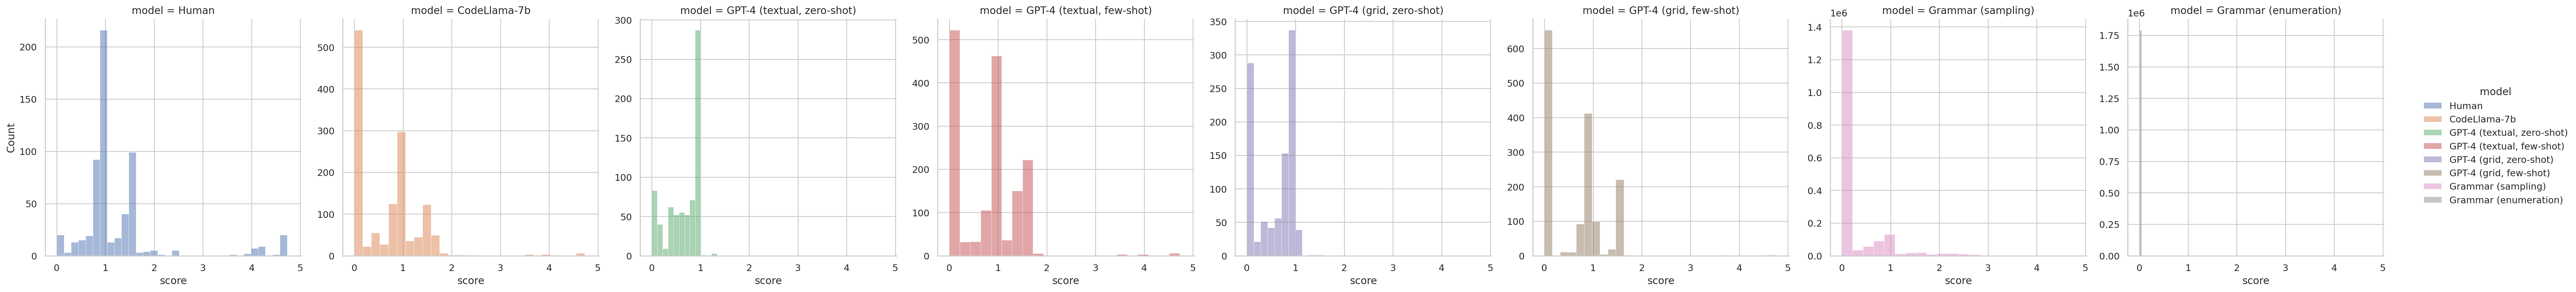

In [15]:
sns.displot(
    data=df_1,
    col="model",
    x="score",
    hue="model",
    common_norm=False,
    common_bins=False,
    facet_kws=dict(sharey=False)
)

### Grouped by trial

Text(0, 0.5, 'EIG')

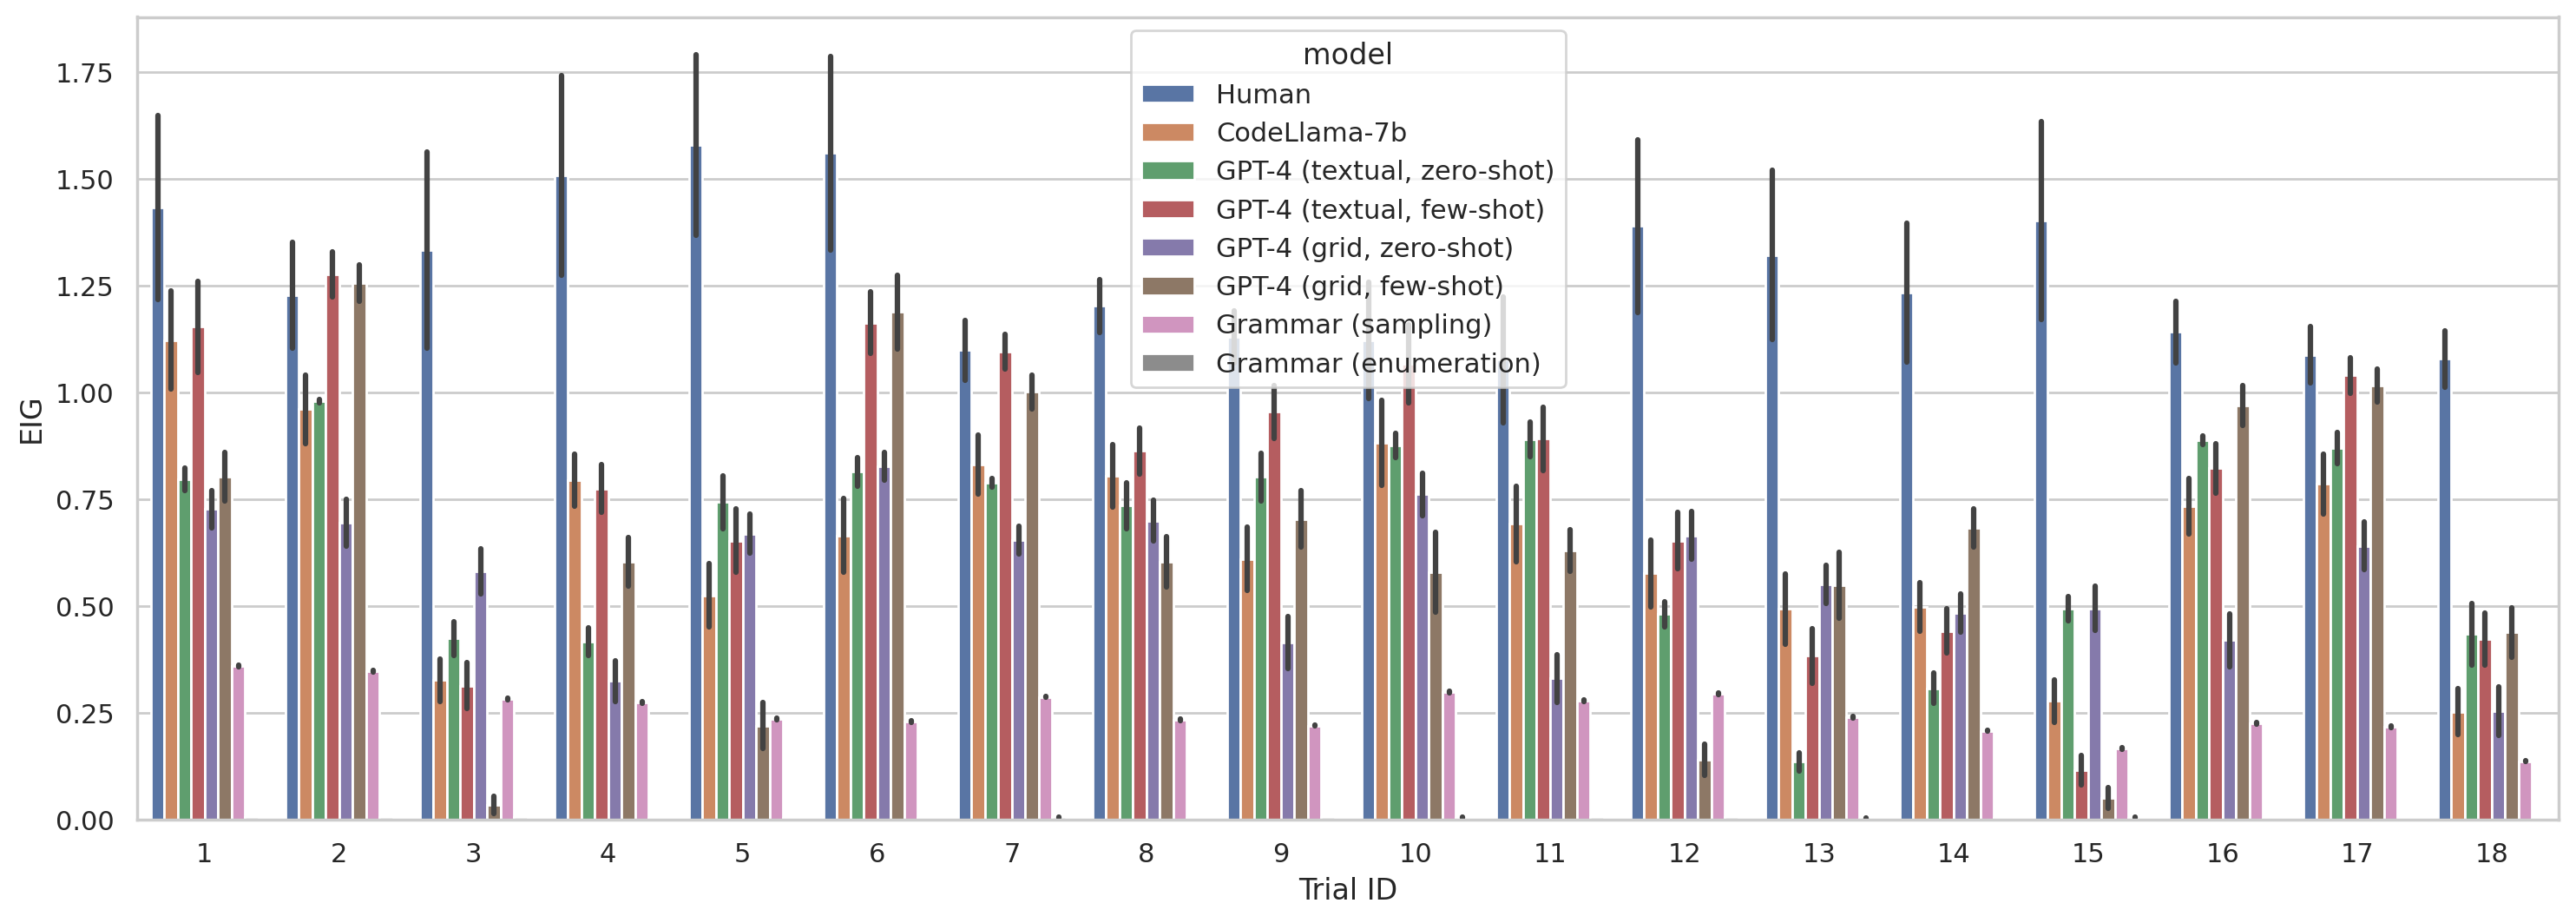

In [16]:
plt.figure(figsize=(18, 6))
sns.barplot(data=df_1, hue="model", x="trial_id", y="score", errorbar="se")
plt.xlabel("Trial ID")
plt.ylabel("EIG")

Text(0, 0.5, 'EIG')

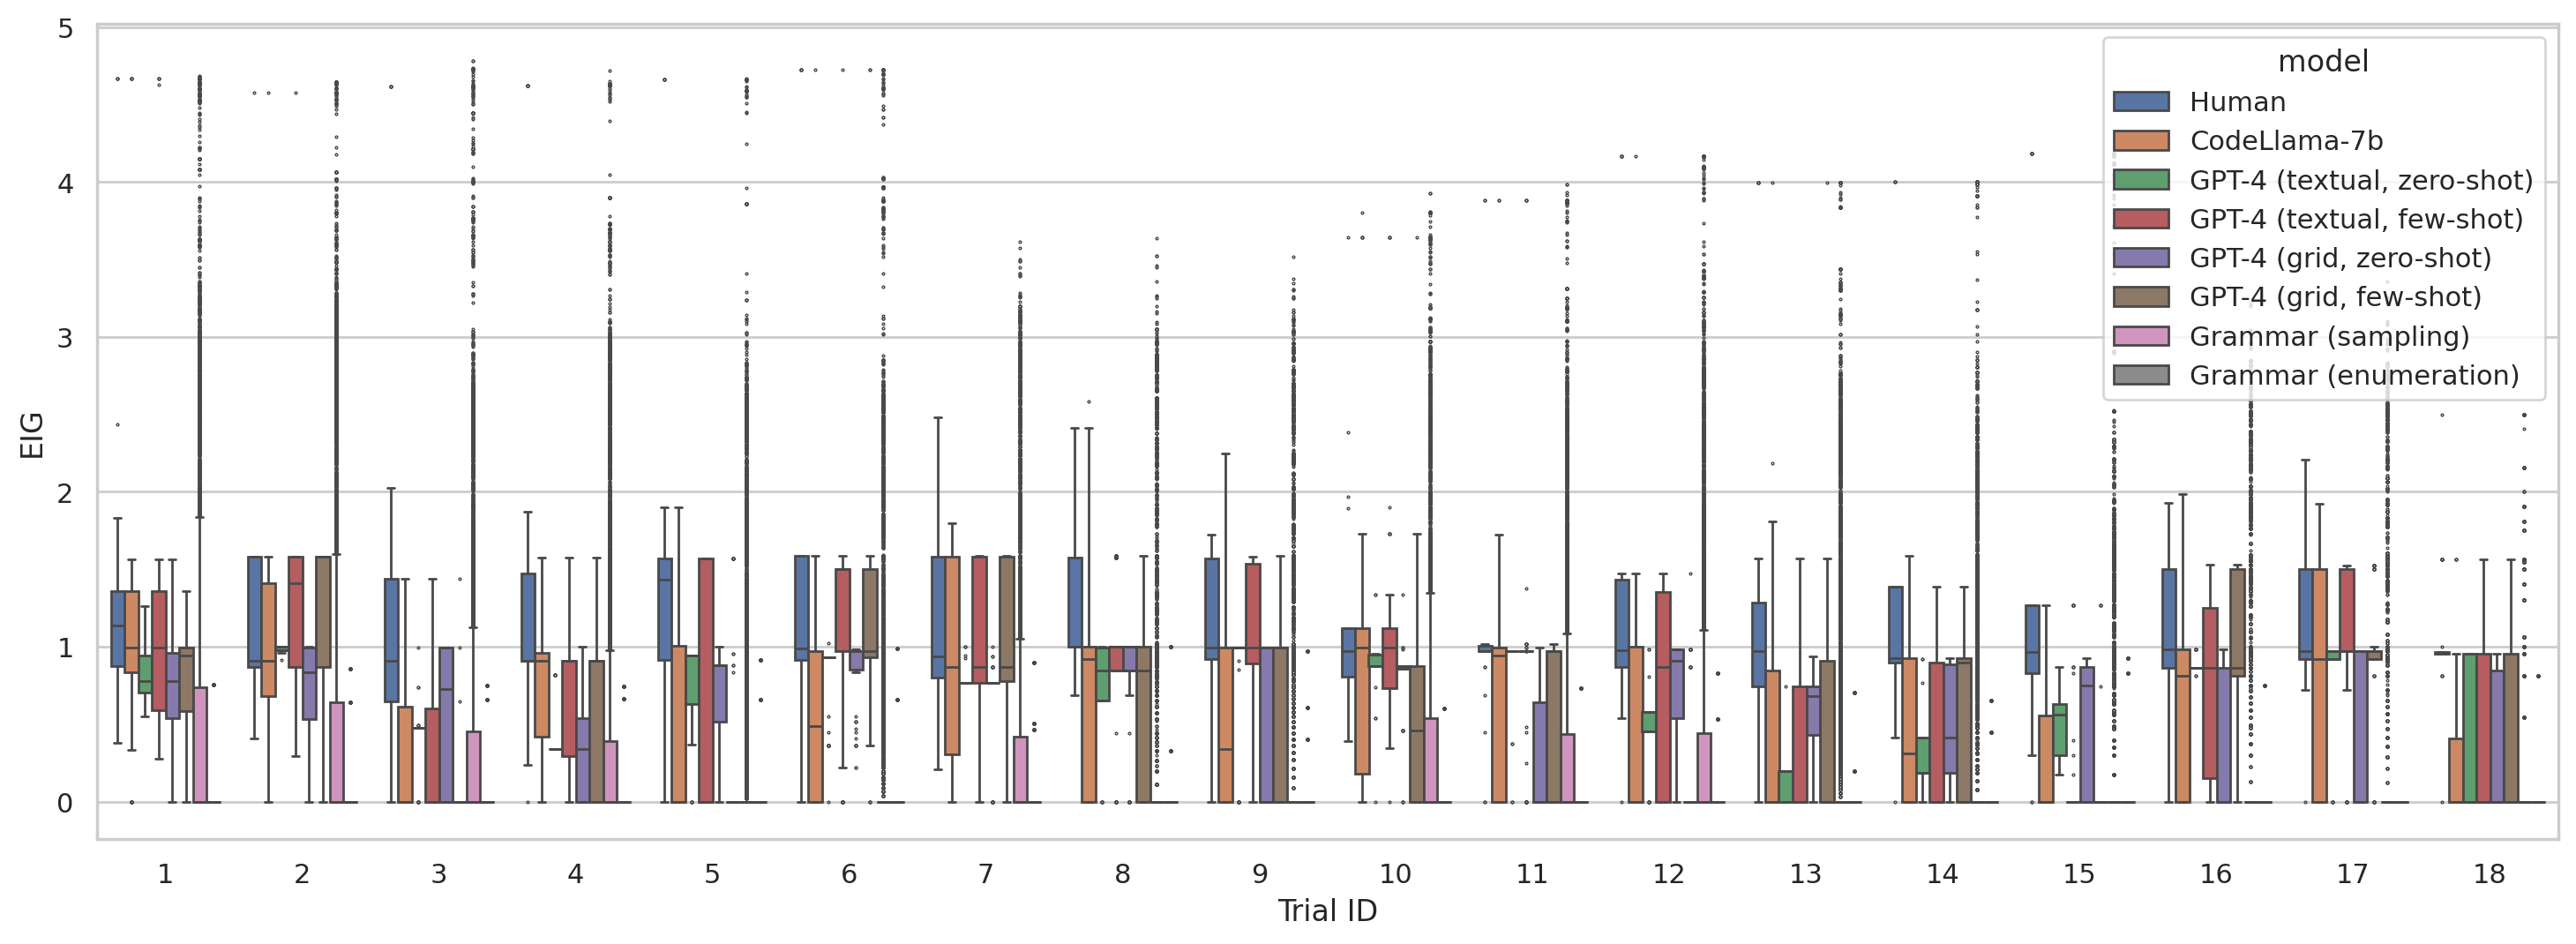

In [17]:
plt.figure(figsize=(18, 6))
# sns.boxplot(data=df, hue="model", x="trial_id", y="score", showfliers=False)
sns.boxplot(
    data=df_1,
    hue="model",
    x="trial_id",
    y="score",
    fliersize=1.0,
    flierprops={"marker": "."},
)
plt.xlabel("Trial ID")
plt.ylabel("EIG")

<Axes: xlabel='trial_id', ylabel='score'>

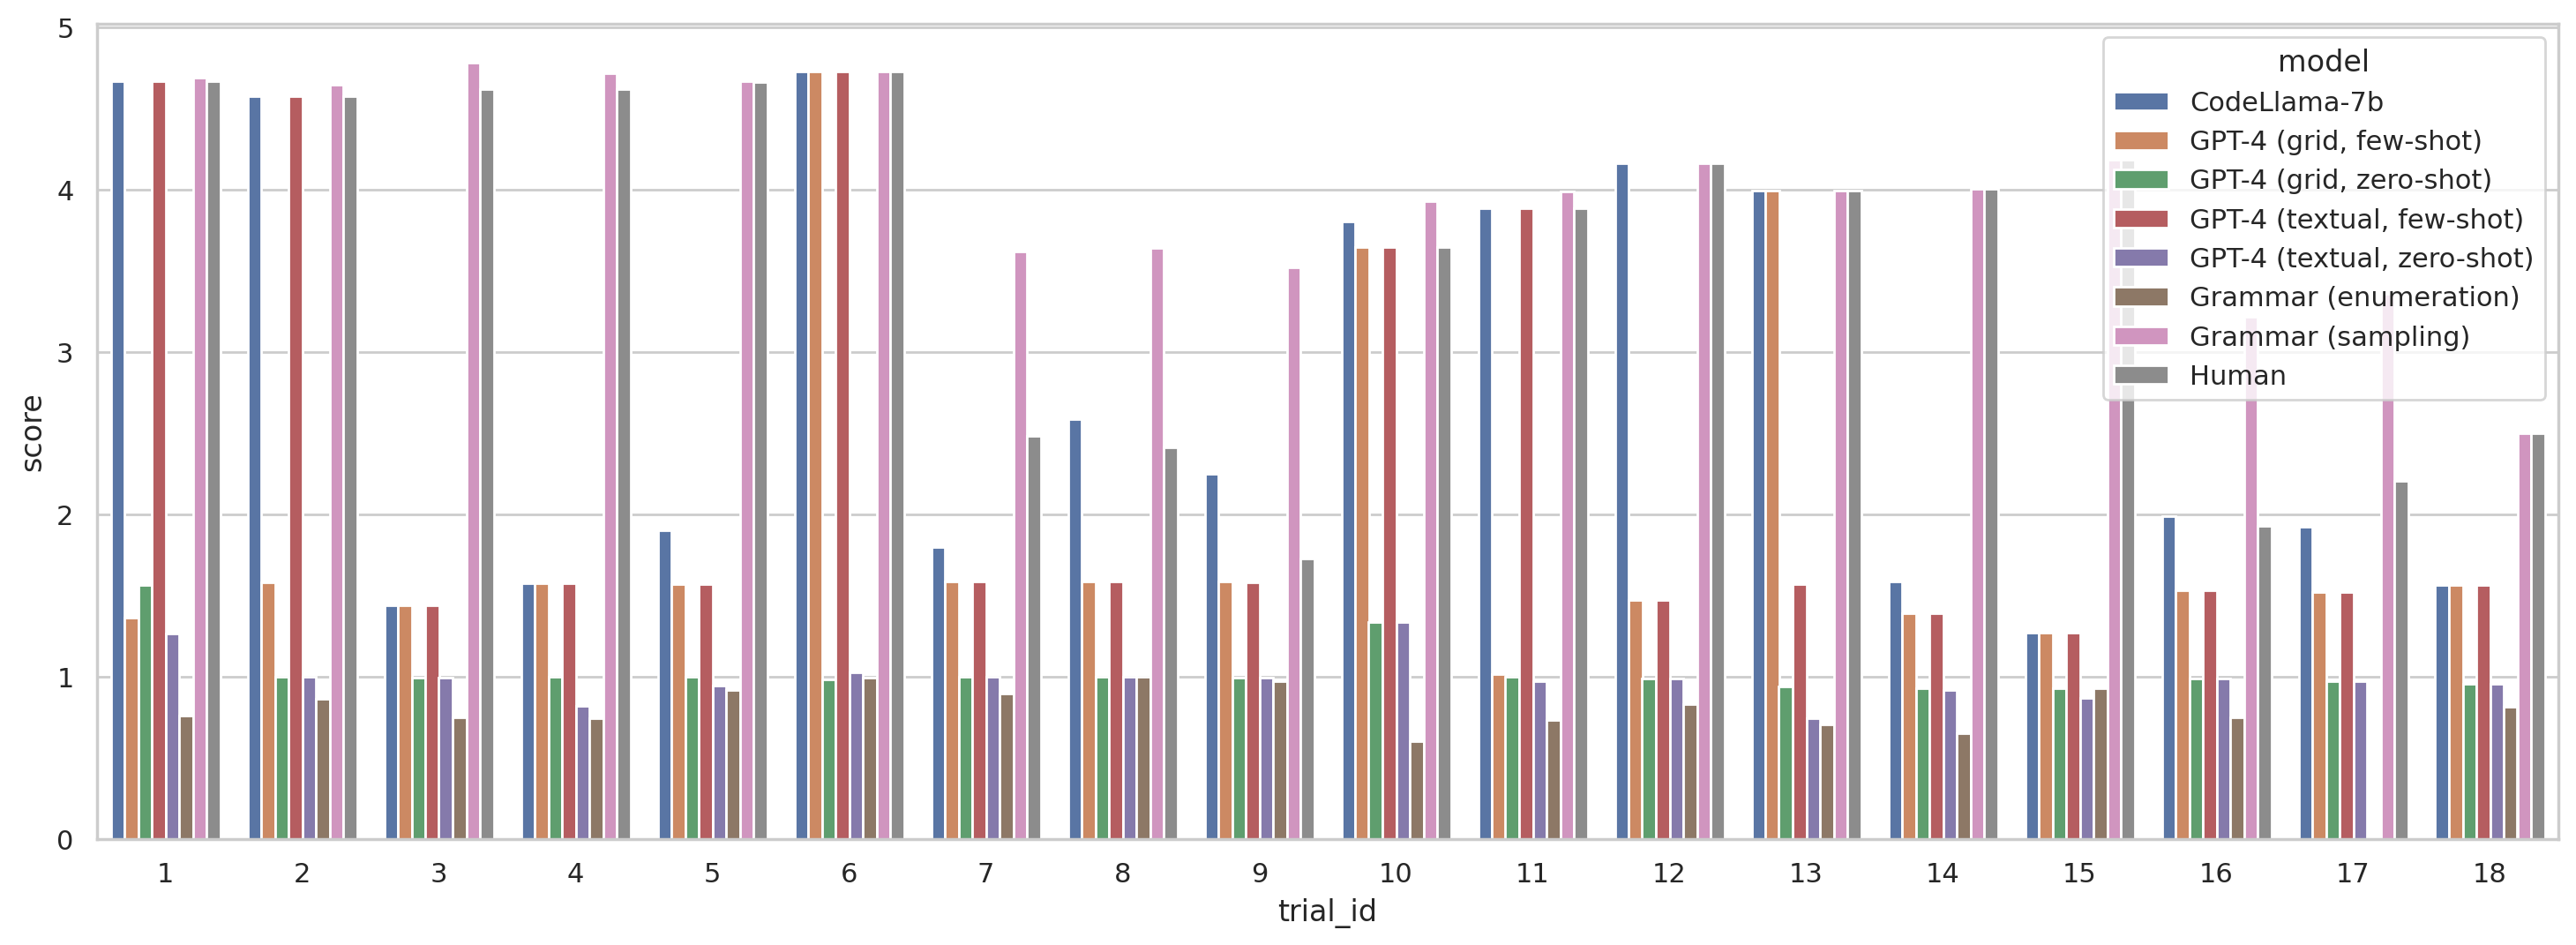

In [18]:
df_max = df_1.groupby(["model", "trial_id"]).score.agg("max")

plt.figure(figsize=(18, 6))
sns.barplot(data=df_max.reset_index(), x="trial_id", y="score", hue="model")

### EIG Percentile

In [62]:
data = []

human_scores = df_human.score.fillna(value=0).values

for (model, k, trial_id), df_group in df.groupby(["model", "k", "trial_id"]):
    scores = df_group.score.fillna(value=0).values
    for i in range(101):
        percentile_of_model = np.percentile(scores, i)
        percentile_of_human = percentileofscore(human_scores, percentile_of_model).item()
        data.append(
            {
                "model": model,
                "k": k,
                "trial_id": trial_id,
                "percentile": i,
                "score": percentile_of_model,
                "percentile_human": percentile_of_human,
            }
        )

df_eig_sum = pd.DataFrame(data)

In [63]:
df_eig_sum

,model,k,trial_id,percentile,score,percentile_human
0,CodeLlama-7b,1,1,0,0.000000,1.735537
1,CodeLlama-7b,1,1,1,0.000000,1.735537
2,CodeLlama-7b,1,1,2,0.000000,1.735537
3,CodeLlama-7b,1,1,3,0.000000,1.735537
4,CodeLlama-7b,1,1,4,0.000000,1.735537
...,...,...,...,...,...,...
78169,Human,1,18,96,1.561278,79.173554
78170,Human,1,18,97,1.561278,79.173554
78171,Human,1,18,98,1.842895,91.074380
78172,Human,1,18,99,2.171447,92.396694


Text(0, 0.5, 'EIG')

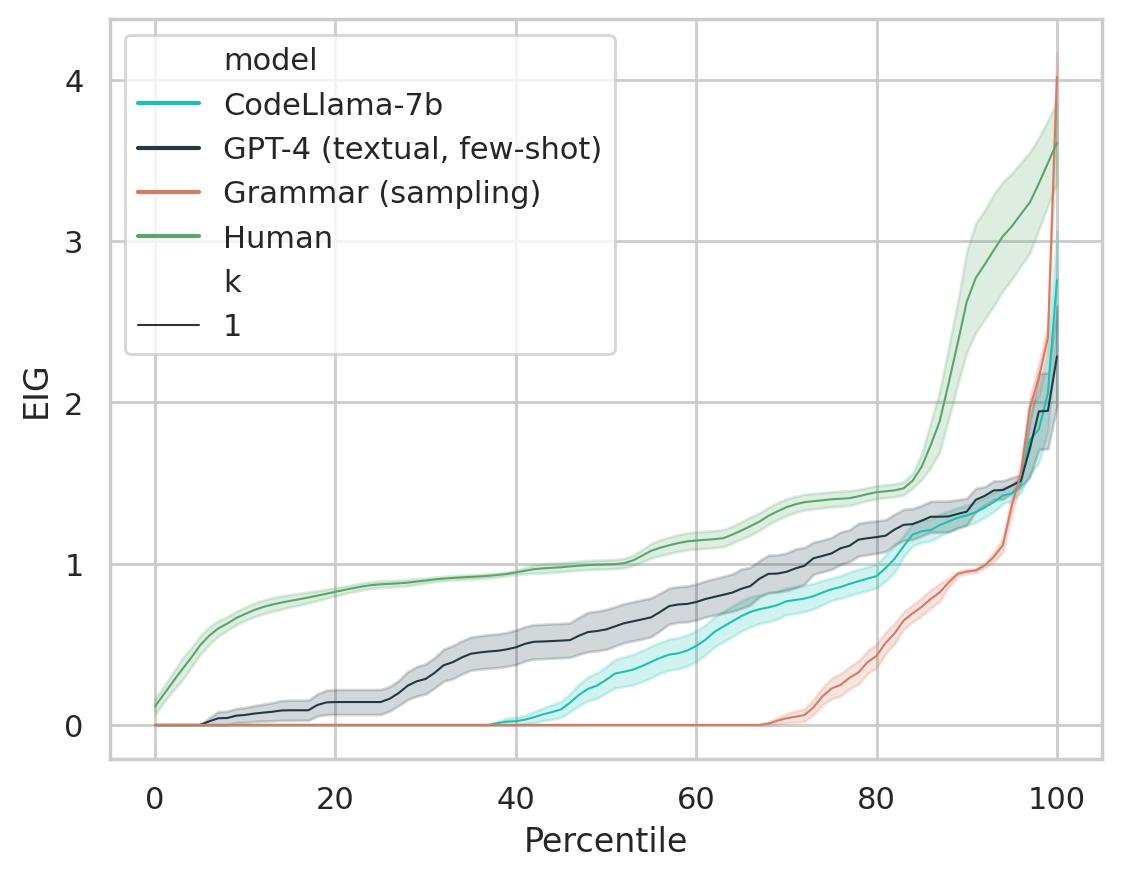

In [64]:
# plt.figure(figsize=(12, 8))
models = ["CodeLlama-7b", "GPT-4 (textual, few-shot)", "Human", "Grammar (sampling)"]
sns.lineplot(
    data=df_eig_sum[(df_eig_sum["k"] <= 1) & (df_eig_sum["model"].isin(models))],
    x="percentile",
    y="score",
    hue="model",
    size="k",
    errorbar="se",
    palette=PALETTE,
)
plt.xlabel("Percentile")
plt.ylabel("EIG")

Text(1696.294756944444, 0.5, 'EIG')

<Figure size 1200x800 with 0 Axes>

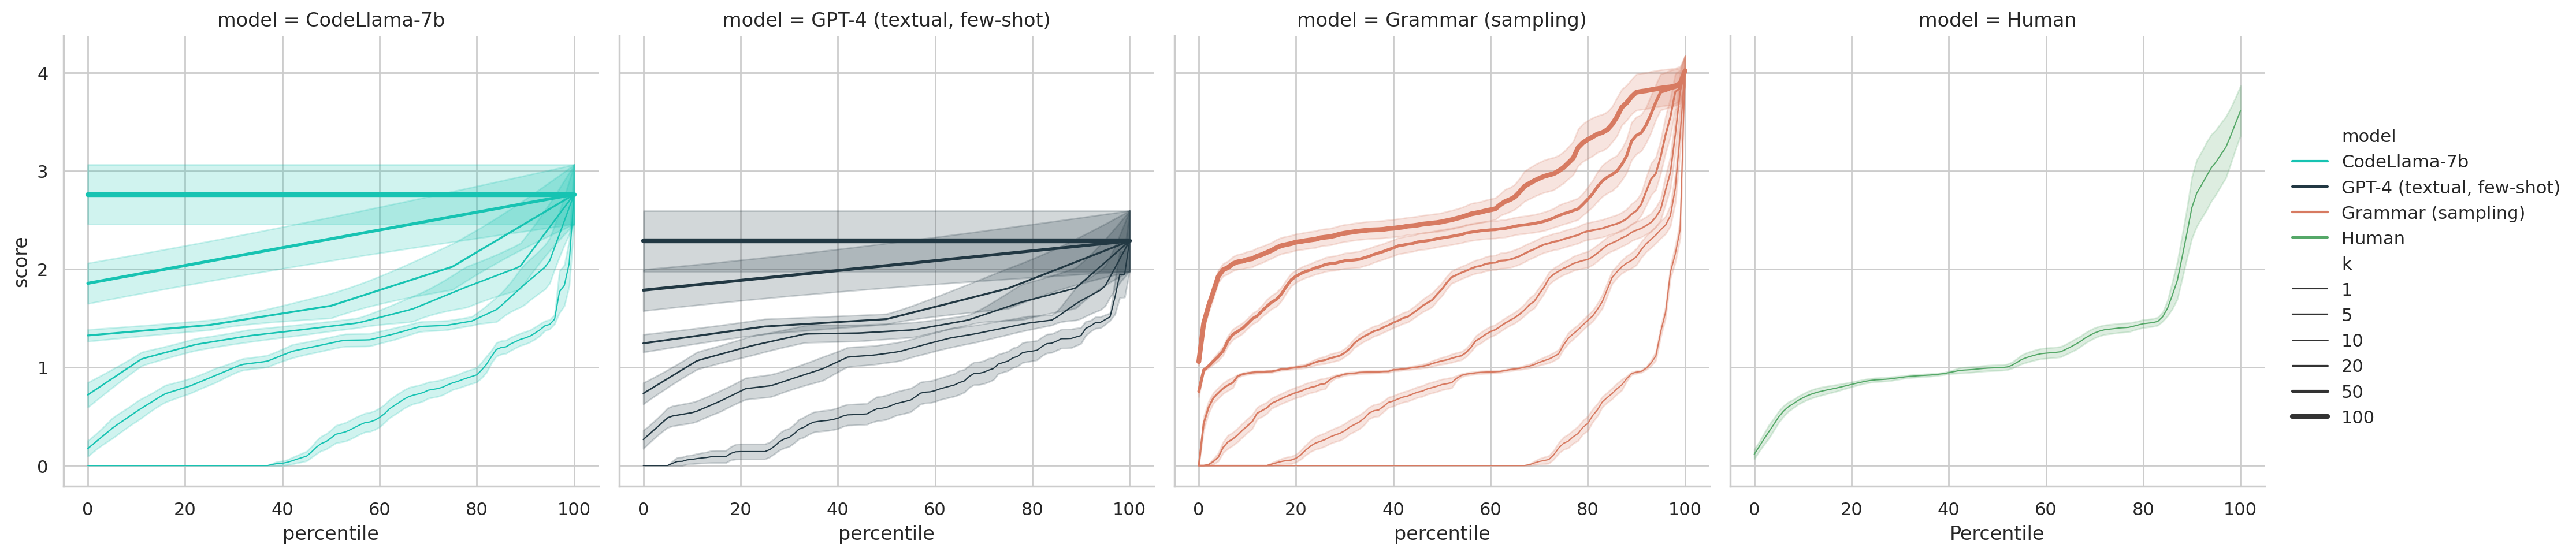

In [71]:
plt.figure(figsize=(12, 8))
models = ["CodeLlama-7b", "GPT-4 (textual, few-shot)", "Human", "Grammar (sampling)"]
sns.relplot(
    kind="line",
    col="model",
    data=df_eig_sum[(df_eig_sum["k"] <= 100) & (df_eig_sum["model"].isin(models))],
    x="percentile",
    y="score",
    hue="model",
    size="k",
    errorbar="se",
    palette=PALETTE,
)
plt.xlabel("Percentile")
plt.ylabel("EIG")

Text(0, 0.5, 'Percentile of Human')

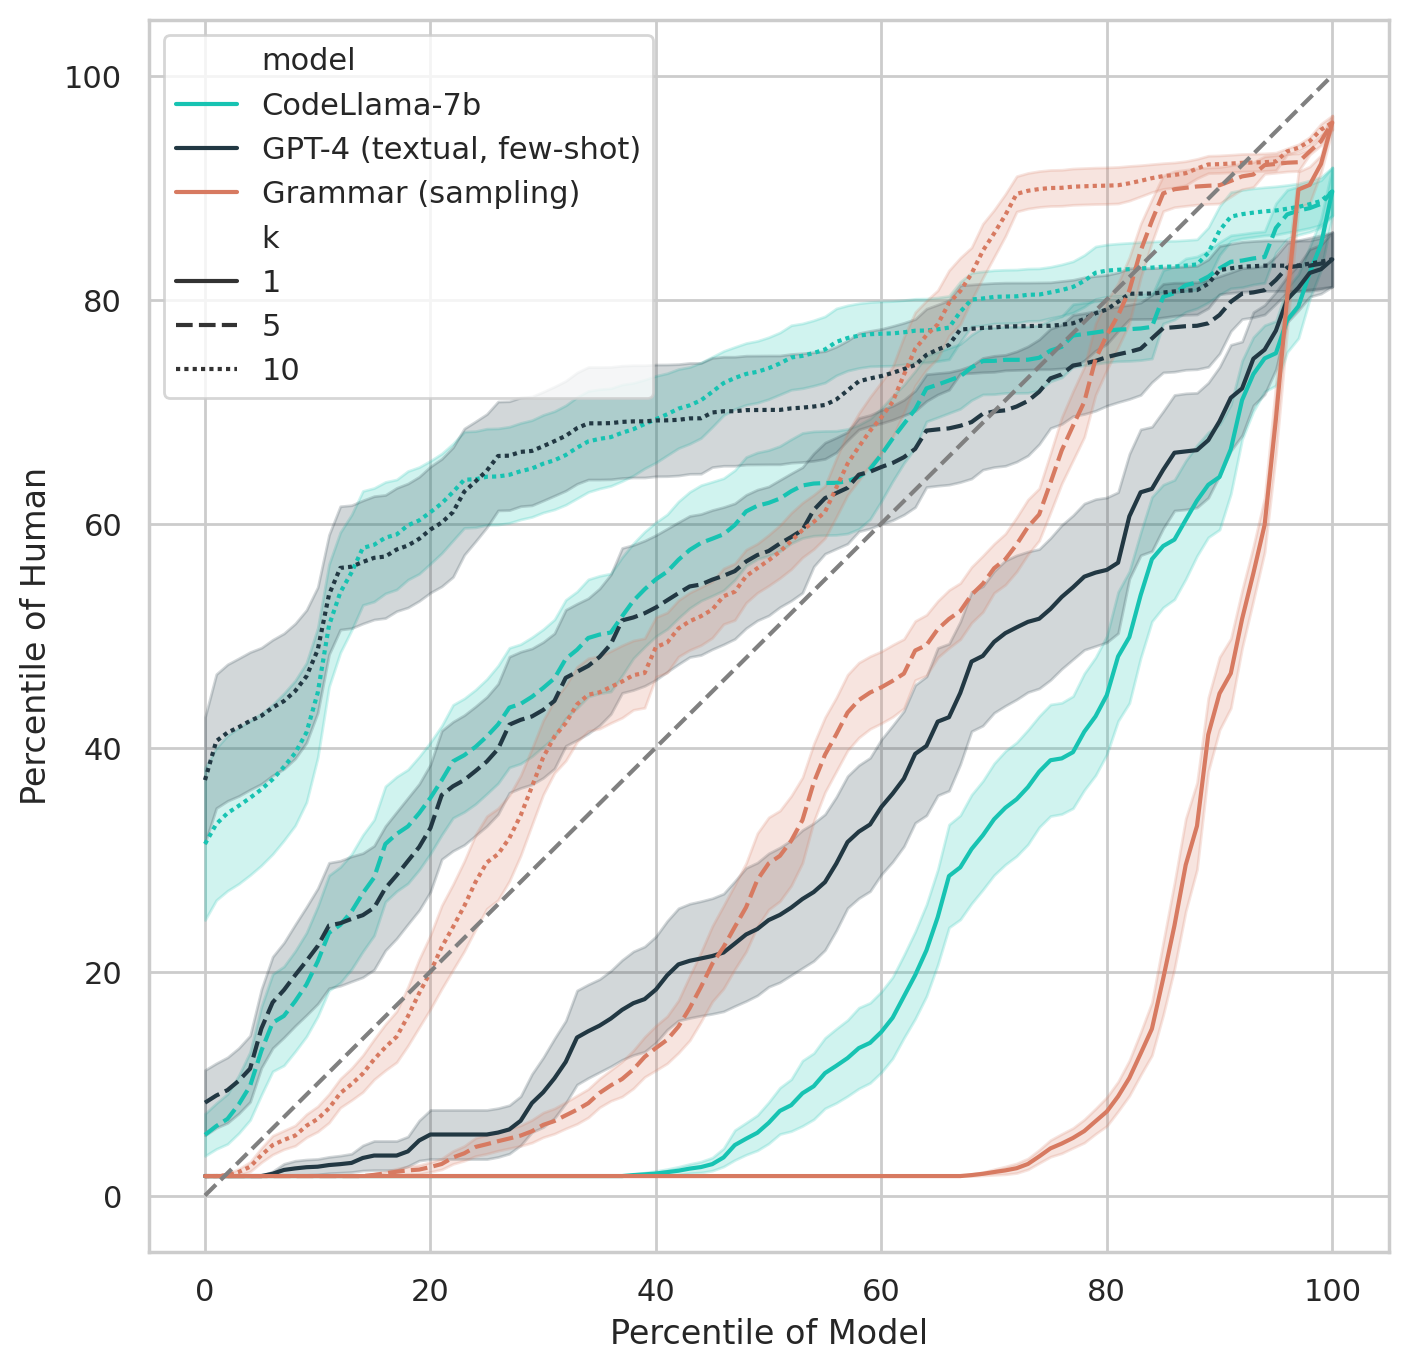

In [77]:
plt.figure(figsize=(8, 8))
models = ["CodeLlama-7b", "GPT-4 (textual, few-shot)", "Grammar (sampling)"]
sns.lineplot(
    data=df_eig_sum[(df_eig_sum["k"] <= 10) & (df_eig_sum["model"].isin(models))],
    x="percentile",
    y="percentile_human",
    hue="model",
    style="k",
    errorbar="se",
    palette=PALETTE,
)

# Draw diagonal line
x = np.linspace(0, 100, 100)
plt.plot(x, x, color="gray", linestyle="--")

plt.xlabel("Percentile of Model")
plt.ylabel("Percentile of Human")

<Figure size 800x800 with 0 Axes>

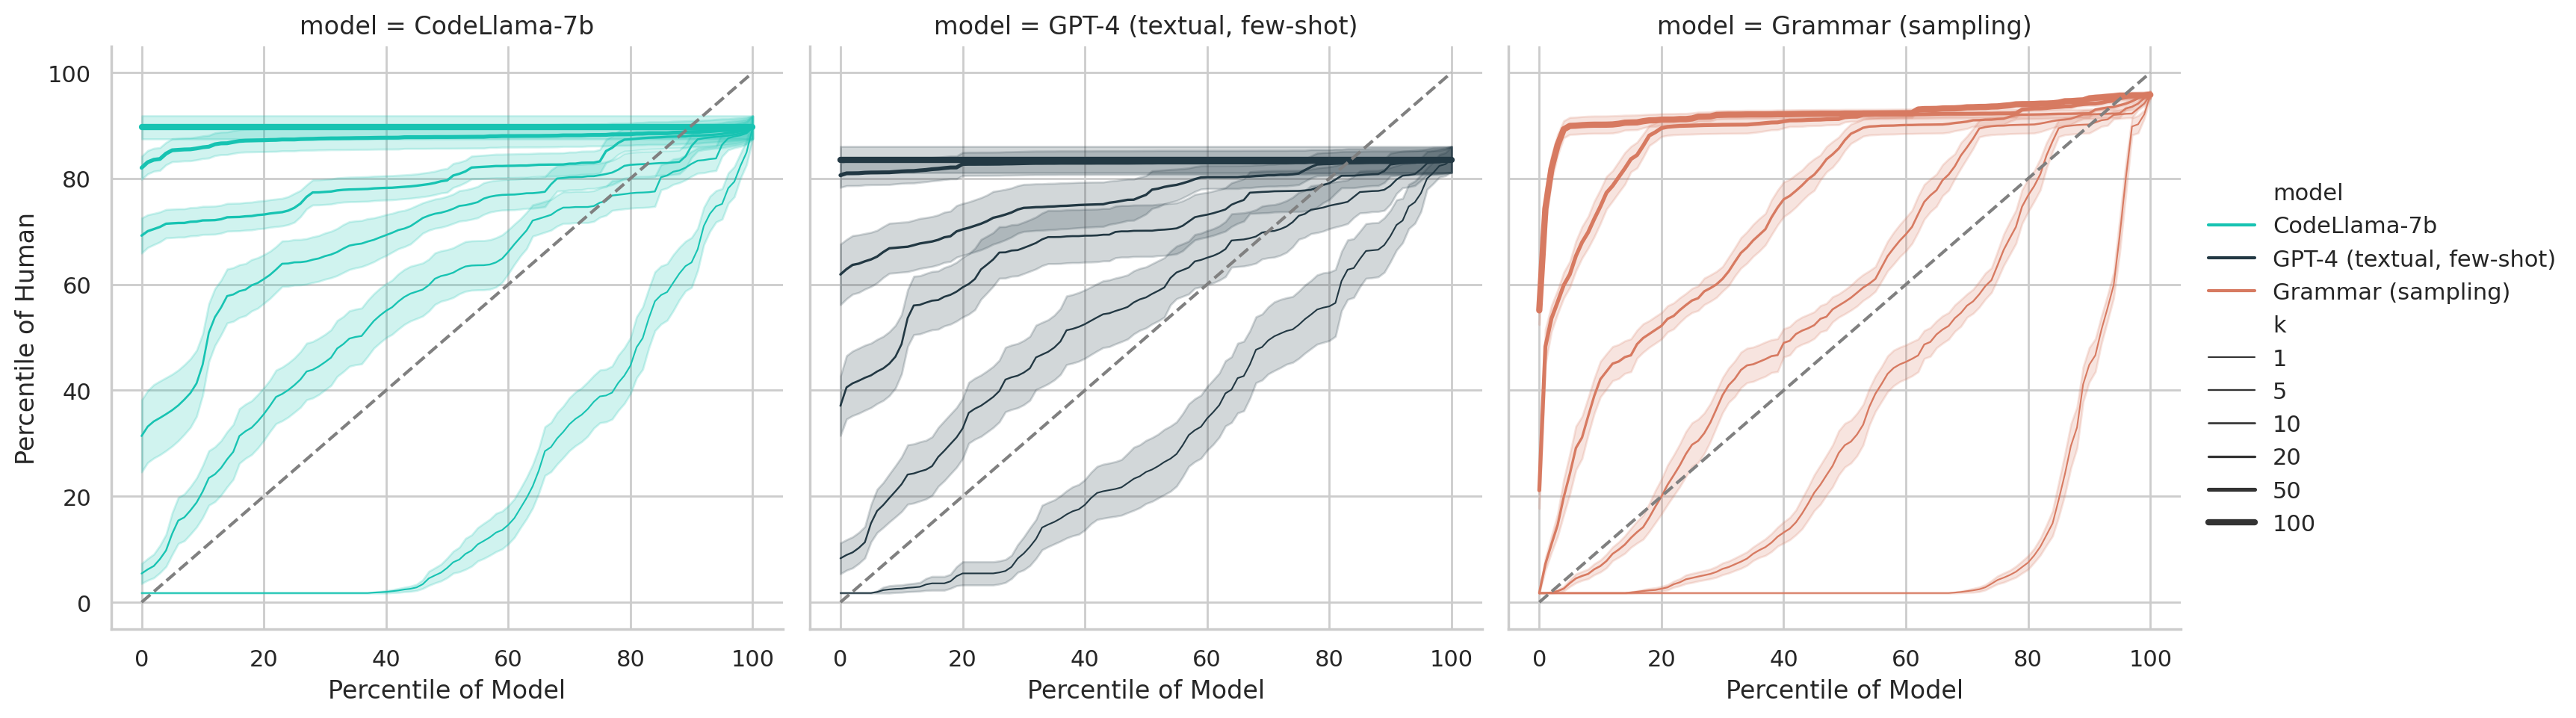

In [92]:
plt.figure(figsize=(8, 8))
models = ["CodeLlama-7b", "GPT-4 (textual, few-shot)", "Grammar (sampling)"]
sns.relplot(
    kind="line",
    data=df_eig_sum[(df_eig_sum["k"] <= 100) & (df_eig_sum["model"].isin(models))],
    col="model",
    x="percentile",
    y="percentile_human",
    hue="model",
    size="k",
    errorbar="se",
    palette=PALETTE,
)

# Draw diagonal line on all plots
for ax in plt.gcf().axes:
    x = np.linspace(0, 100, 100)
    ax.plot(x, x, color="gray", linestyle="--")

    ax.set_xlabel("Percentile of Model")
    ax.set_ylabel("Percentile of Human")


## General EIG dists

Text(0, 0.5, 'EIG')

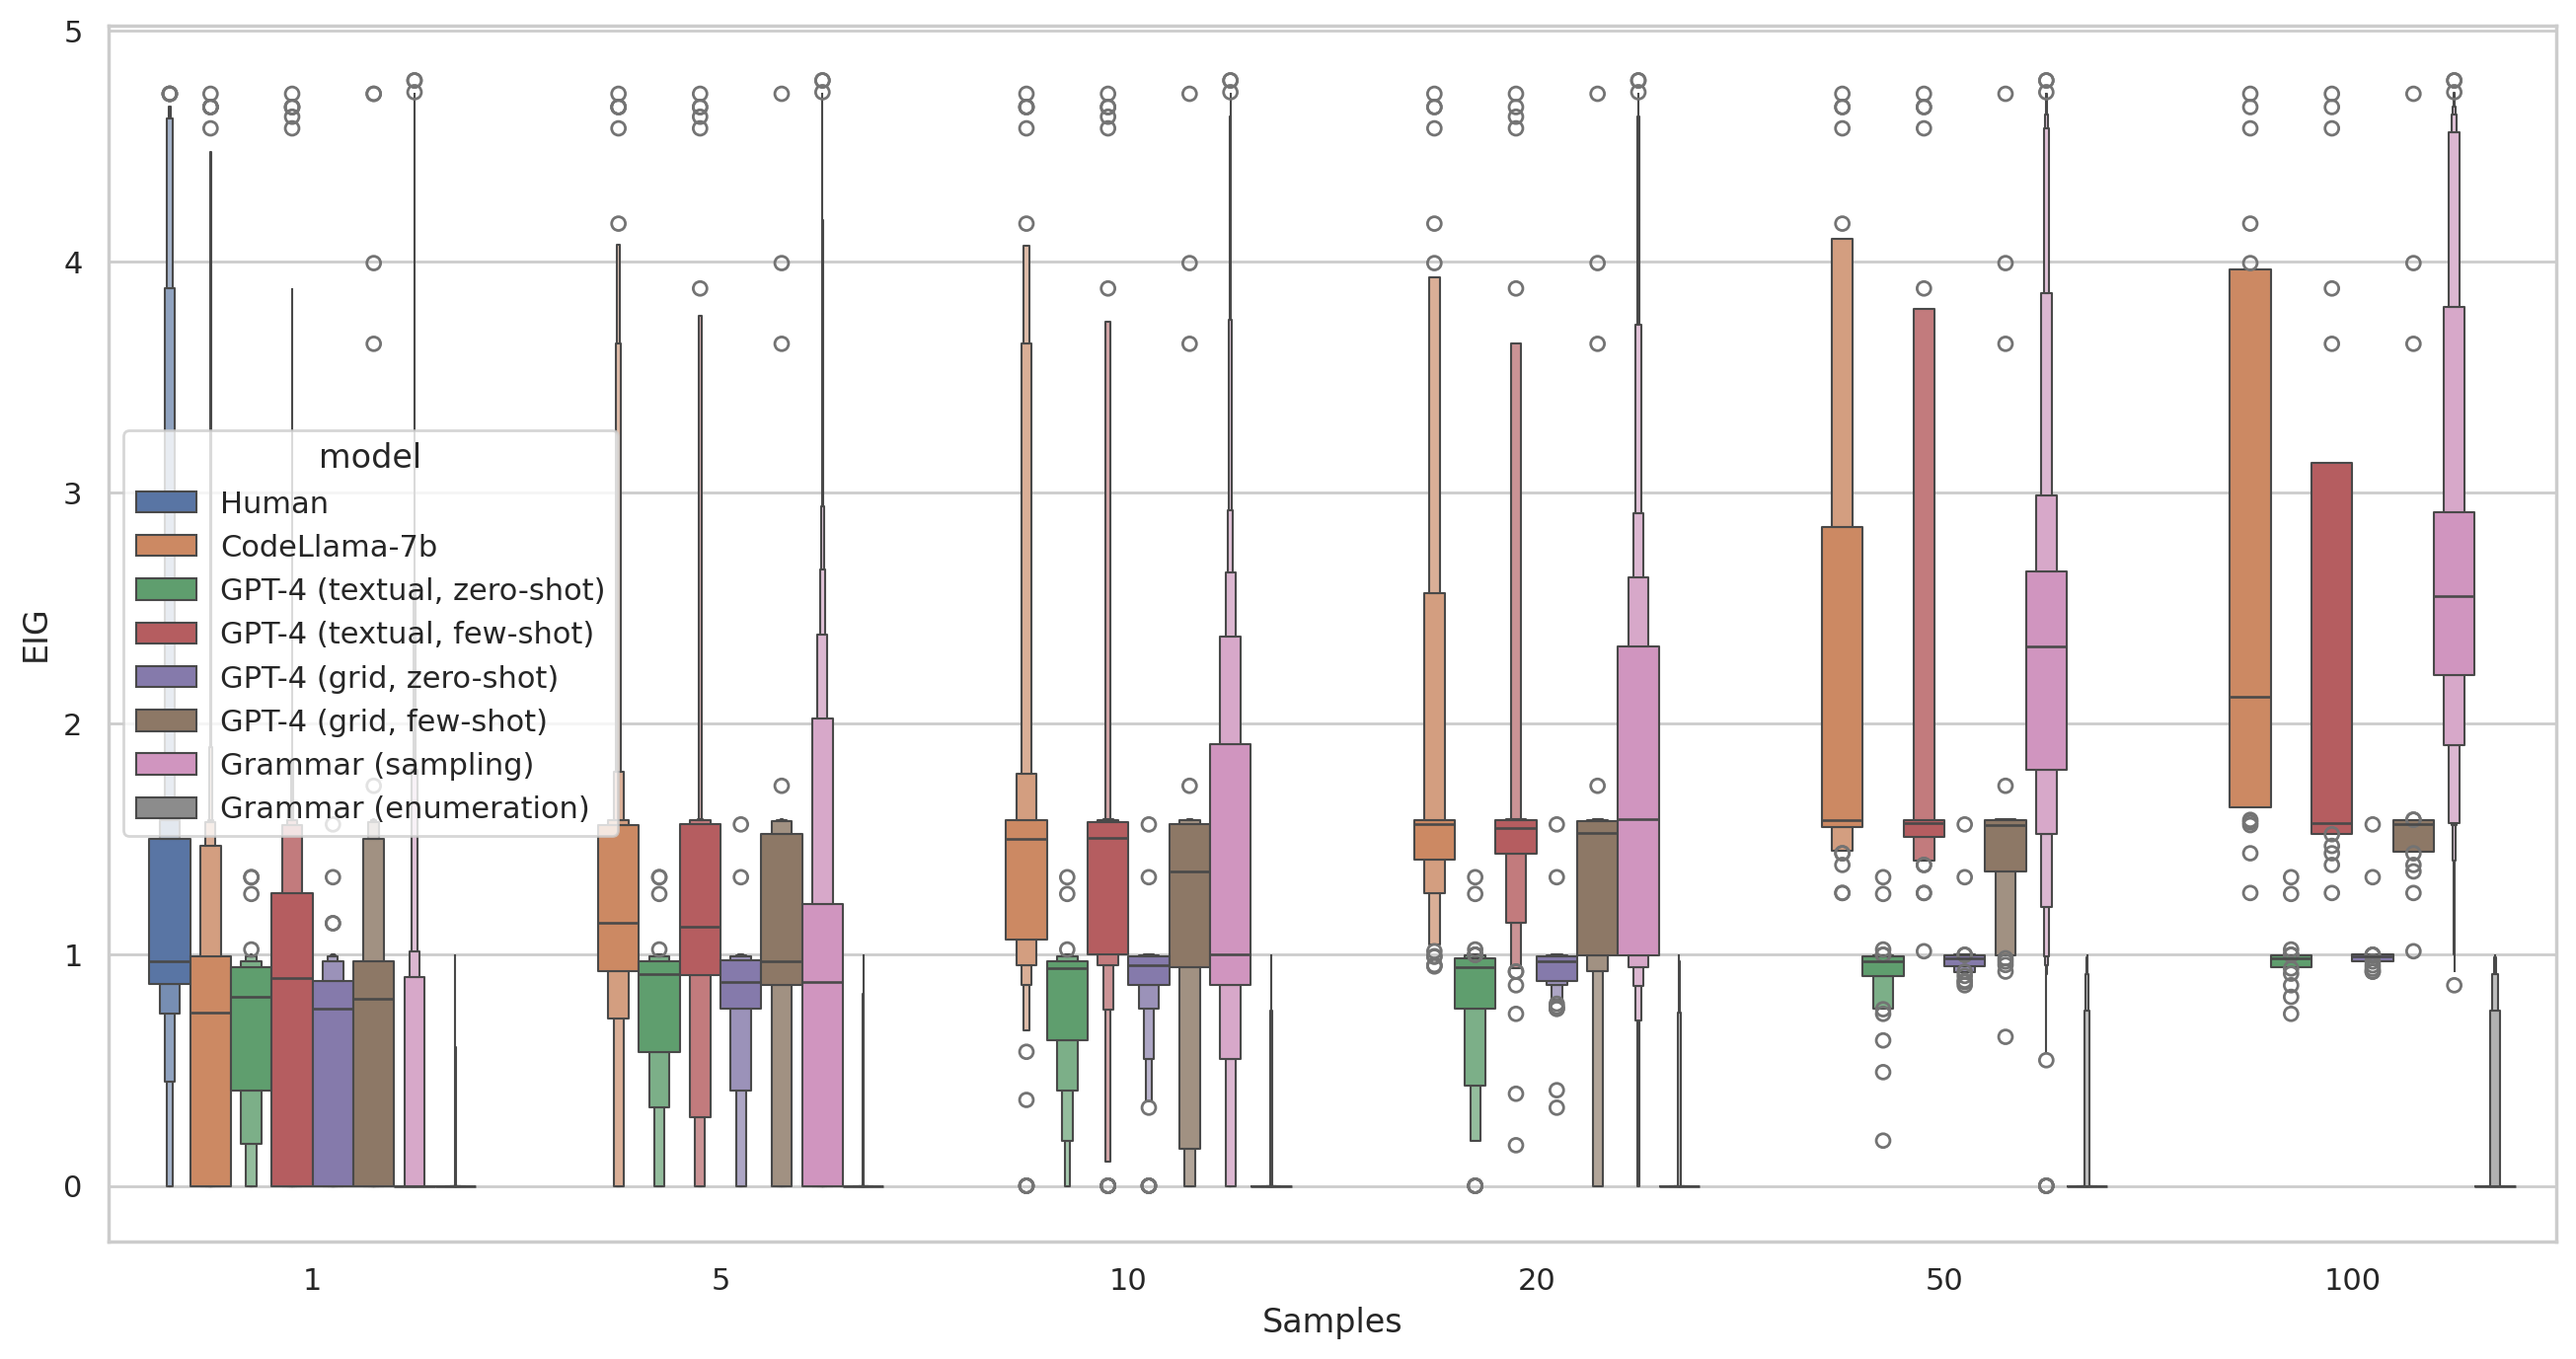

In [20]:
plt.figure(figsize=(16, 8))
# sns.pointplot(data=df, x="k", y="score", hue="model", errorbar="se")
sns.boxenplot(data=df, x="k", y="score", hue="model")
plt.xlabel("Samples")
plt.ylabel("EIG")
# plt.xscale("log")

Text(576.4598194444446, 0.5, 'EIG')

<Figure size 1600x800 with 0 Axes>

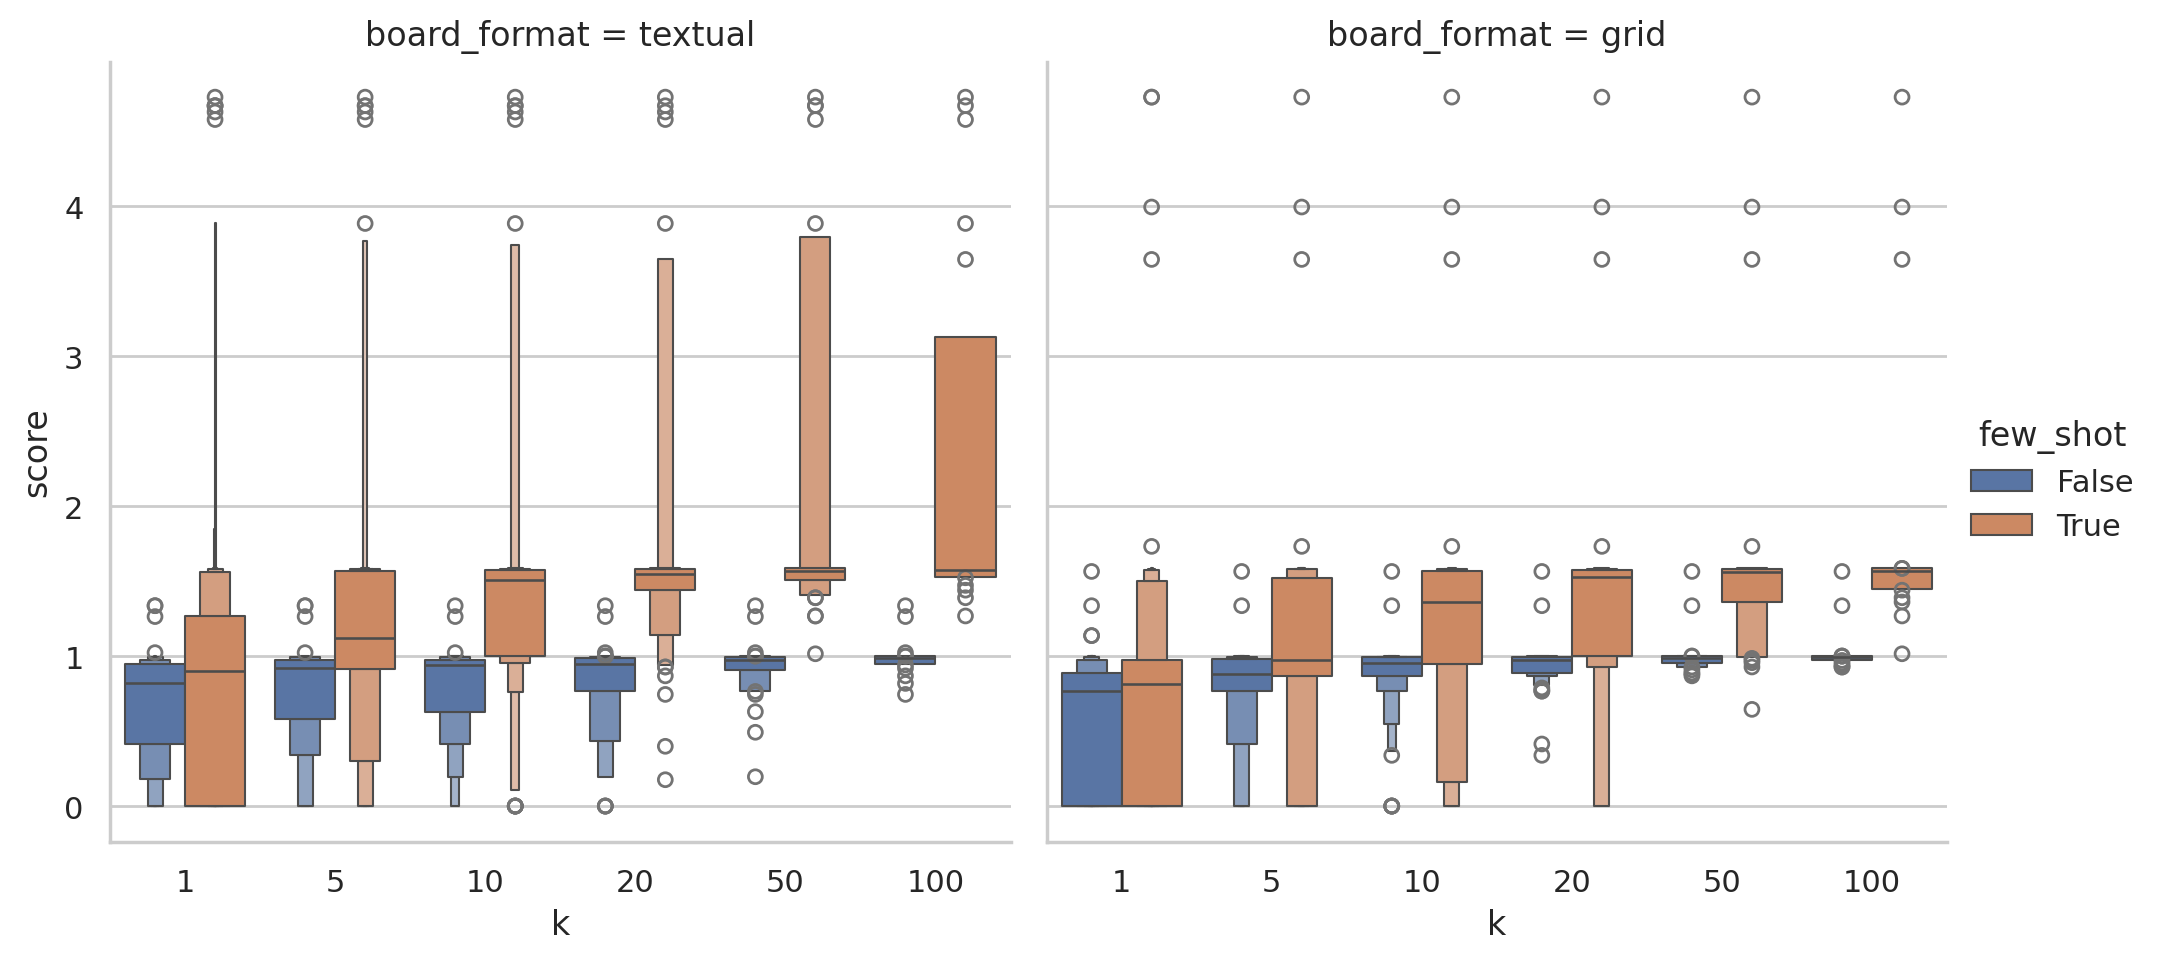

In [93]:
plt.figure(figsize=(16, 8))
sns.catplot(kind="boxen", data=df[df.model.str.contains("GPT-4")], x="k", y="score", hue="few_shot", col="board_format")

# sns.lineplot(data=df[df.model.str.contains("GPT-4")], x="k", y="score", hue="board_format", style="few_shot", markers=["o", "o"])
# plt.xlabel("Samples")
plt.ylabel("EIG")
# plt.xscale("log")

In [94]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=df[df.model.str.contains("GPT-4")], x="k", y="score", hue="board_format", style="few_shot", markers=["o", "o"])
plt.xlabel("Samples")
plt.ylabel("EIG")
plt.xscale("log")

ValueError: The palette dictionary is missing keys: {'grid', 'textual'}

<Figure size 1600x800 with 0 Axes>

In [23]:
human_mean = df[df.model == "Human"].groupby("trial_id").score.mean().mean()
print(f"Human mean: {human_mean:.3f}")

human_max = df[df.model == "Human"].groupby("trial_id").score.max().mean()
print(f"Human max: {human_max:.3f}")

Human mean: 1.274
Human max: 3.611


Text(0, 0.5, 'EIG')

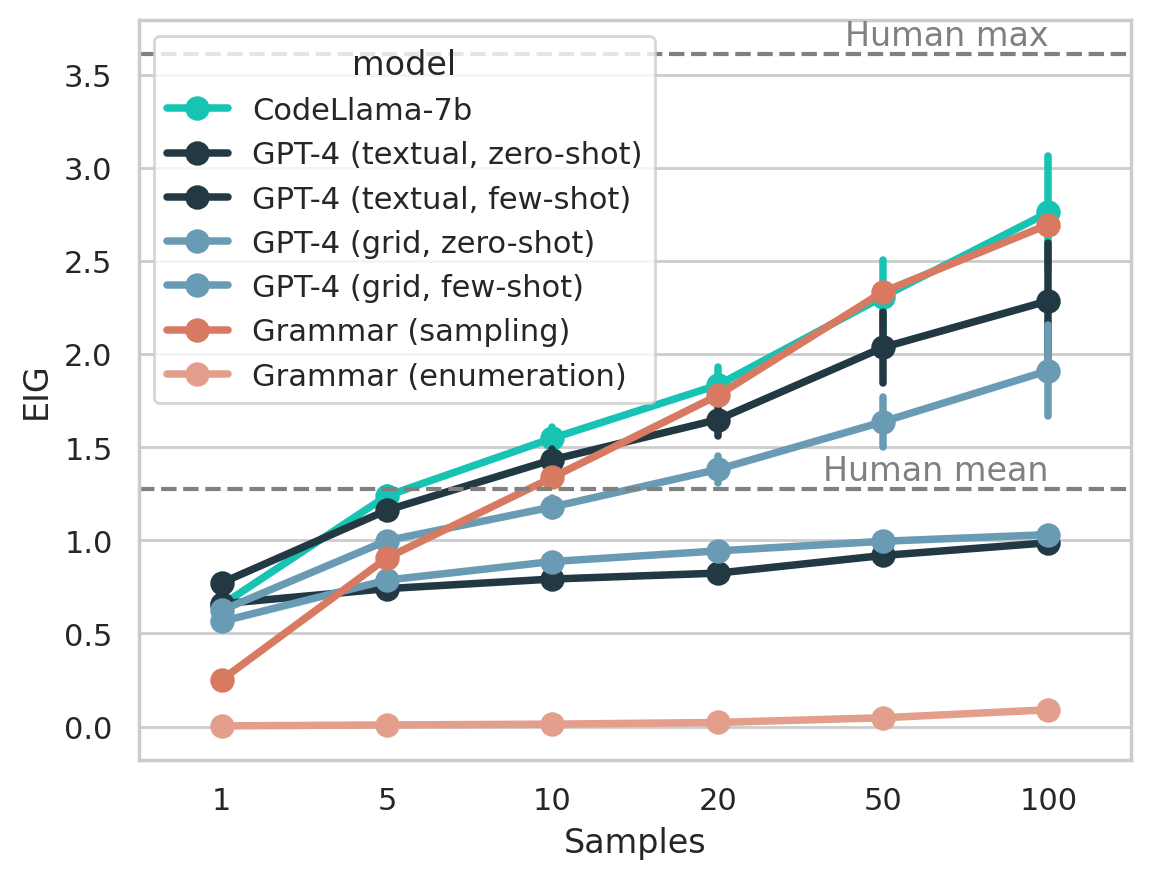

In [35]:
# plt.figure(figsize=(16, 8))

sns.pointplot(data=df[df.model != "Human"], x="k", y="score", hue="model", errorbar="se", palette=PALETTE)

# Add lines for human mean and max
plt.axhline(human_mean, color="gray", linestyle="--")
plt.axhline(human_max, color="gray", linestyle="--")

# Add labels for human mean and max
plt.text(5, human_mean + 0.01, "Human mean", ha="right", va="bottom", color="gray")
plt.text(5, human_max + 0.01, "Human max", ha="right", va="bottom", color="gray")


plt.xlabel("Samples")
plt.ylabel("EIG")
# plt.xscale("log")

In [25]:
df.sort_values("score", ascending=False).head(100).program.tolist()

['( bottomright ( union ( unique ( setDifference ( setDifference ( unique ( unique ( unique ( coloredTiles Water ) ) ) ) ( set AllTiles ) ) ( unique ( intersection ( set AllTiles ) ( coloredTiles Water ) ) ) ) ) ( unique ( unique ( setDifference ( intersection ( unique ( coloredTiles Red ) ) ( set AllTiles ) ) ( coloredTiles ( color 3D ) ) ) ) ) ) )',
 '( bottomright ( union ( unique ( setDifference ( setDifference ( unique ( unique ( unique ( coloredTiles Water ) ) ) ) ( set AllTiles ) ) ( unique ( intersection ( set AllTiles ) ( coloredTiles Water ) ) ) ) ) ( unique ( unique ( setDifference ( intersection ( unique ( coloredTiles Red ) ) ( set AllTiles ) ) ( coloredTiles ( color 3D ) ) ) ) ) ) )',
 '( bottomright ( union ( unique ( setDifference ( setDifference ( unique ( unique ( unique ( coloredTiles Water ) ) ) ) ( set AllTiles ) ) ( unique ( intersection ( set AllTiles ) ( coloredTiles Water ) ) ) ) ) ( unique ( unique ( setDifference ( intersection ( unique ( coloredTiles Red ) )